# Decision Theory: Expected Utility and Decision Trees

Probability distributions tell you what *might* happen. Decision theory tells you what to *do about it*. This chapter bridges the gap between quantified uncertainty and actionable choices, using security investment as the running example.

Most security teams already make decisions under uncertainty — they just do it informally, using experience, vendor advice, and executive intuition. Decision theory does not replace judgment; it provides a framework for making the judgment *explicit*, *repeatable*, and *auditable*. When you can show exactly which assumptions drove a recommendation, you can also show exactly what would need to change for a different recommendation to win.

This notebook covers:

1. Decision trees for structuring choices under uncertainty
2. Expected value (risk-neutral) decisions
3. Expected utility (risk-averse) decisions
4. Monte Carlo decision analysis with full loss distributions
5. Expected Value of Perfect Information (EVPI)
6. EVSI: what imperfect information is actually worth
7. Opportunity loss and regret framing
8. Greedy control selection under budget constraints

## Setup

We use the Monte Carlo engine for loss simulation, VOI functions for EVPI
and control selection, and `synth` for reproducible random generation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from decision_security.synth import make_rng
from decision_security.montecarlo import (
    simulate_aggregate_losses,
    make_lognormal_severity,
    risk_bands,
)
from decision_security.voi import evpi, select_controls_by_roi

rng = make_rng(42)

# Benedict Wilson style (Stoikeia papers)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRIMARY = "#1A1A1A"
ACCENT = "#E74C3C"
DARK_BG = "#34495E"
LIGHT_GRAY = "#95A5A6"
MED_GRAY = "#7F8C8D"
VERY_LIGHT = "#BDC3C7"


## Decision Tree: Deploy EDR Now vs. Wait

A decision model separates what you control from what you don't. **Decision nodes** (squares in a tree diagram) represent choices — deploy EDR now or next quarter, fund a red-team exercise or spend on phishing training. **Chance nodes** (circles) represent uncertain events — whether an attacker targets you this year, whether a vulnerability is exploitable. Connecting them in a tree forces you to spell out every assumption that is otherwise buried in a slide deck or a gut call.

The discipline of drawing the tree matters as much as computing the answer. Each branch requires you to name the alternatives (not just the one you already prefer), assign probabilities to chance events (not just "likely" or "unlikely"), and attach outcomes to every terminal node. This structure alone eliminates a surprising number of bad decisions — the ones that fail not because the math was wrong but because an option or a risk was never considered.

A security team faces a classic decision: deploy an EDR solution now (incurring a certain cost) or wait and accept the risk of a breach.

```
                          ┌── Breach (p=0.3) ──── Loss: $800K
             ┌─ Wait ─────┤
             │            └── No breach (p=0.7) ── Loss: $0
  [Decision] ┤
             │            ┌── Breach (p=0.3) ──── Loss: $200K (EDR cost only)
             └─ Deploy ───┤                       (EDR contains the breach)
                          └── No breach (p=0.7) ── Loss: $200K (EDR cost)
```

Assumptions for the simple model:
- Breach probability: 0.3 over the decision horizon
- Unmitigated breach cost: $800K
- EDR annual cost: $200K
- If EDR is deployed and breach occurs, EDR fully contains it (loss = EDR cost only)

Even writing this down as a two-branch tree makes the implicit bet visible — something a verbal debate rarely achieves.

## Expected Value Decision

The simplest rule is **expected value (EV)**: multiply each outcome by its probability, sum, and pick the option with the highest total (or lowest total cost). A risk-neutral decision-maker — one who only cares about the long-run average — would always follow this rule.

For the EDR example, if the breach probability is 30%, the EV of waiting is $0.30 \times \$800\text{K} = \$240\text{K}$, while deploying costs a certain $\$200\text{K}$. The difference is small — only $\$40\text{K}$ — which means the decision is sensitive to secondary factors and to the precision of your probability estimate.

But expected value treats every dollar identically, whether it is the first dollar or the dollar that triggers insolvency. Most organizations are *not* risk-neutral. A $\$240\text{K}$ expected loss that occasionally produces a $\$800\text{K}$ hit may be worse than a guaranteed $\$200\text{K}$ spend, even though the EV says otherwise. That is where expected utility comes in.

In [2]:
breach_prob = 0.3
breach_cost = 800_000
edr_cost = 200_000

# Wait branch: expected loss
ev_wait = breach_prob * breach_cost + (1 - breach_prob) * 0

# Deploy branch: EDR cost is certain; breach still possible but contained
ev_deploy = edr_cost  # $200K regardless of breach outcome

print(f"EV(Wait)   = ${ev_wait:,.0f}")
print(f"EV(Deploy) = ${ev_deploy:,.0f}")
print()
if ev_deploy < ev_wait:
    print(f"Risk-neutral choice: Deploy EDR (saves ${ev_wait - ev_deploy:,.0f} in expectation)")
else:
    print(f"Risk-neutral choice: Wait (saves ${ev_deploy - ev_wait:,.0f} in expectation)")

EV(Wait)   = $240,000
EV(Deploy) = $200,000

Risk-neutral choice: Deploy EDR (saves $40,000 in expectation)


## Expected Utility: Risk Aversion Changes the Answer

Expected value treats every dollar of loss equally. But most organizations are *risk-averse* — an $\$800\text{K}$ loss hurts more than four times as much as a $\$200\text{K}$ loss. **Expected utility** replaces dollar outcomes with a utility function $u(\cdot)$.

A **concave** utility function — $u(x) = \sqrt{x}$, $u(x) = \ln(x)$, or the exponential form used here — captures risk aversion: losing $\$10\text{M}$ hurts more than gaining $\$10\text{M}$ helps. The decision rule becomes: choose the option that maximizes $\mathbb{E}[u(X)]$.

We model this with an exponential utility function:

$$u(x) = -\exp\left(-\frac{x}{\rho}\right)$$

where $\rho$ is the **risk tolerance parameter**. Smaller $\rho$ means more risk-averse. We use $\rho = 500{,}000$ here.

Why does this distinction matter for security? Consider two controls with equal expected-value reduction of $\$500\text{K}$. Control A reduces many small incidents; Control B reduces a single catastrophic scenario. Under expected value they are equivalent, but under a concave utility function the catastrophic-loss reduction is worth more — which matches how most executives actually think. Expected utility formalizes that preference rather than leaving it as an unstated assumption.

In [3]:
rho = 500_000  # risk tolerance

def utility(x):
    """Exponential utility: u(x) = -exp(-x / rho).
    x is a *cost* (negative outcome), so higher x = worse."""
    return -np.exp(-x / rho)

# Expected utility of each branch
eu_wait = breach_prob * utility(breach_cost) + (1 - breach_prob) * utility(0)
eu_deploy = utility(edr_cost)  # certain outcome

print(f"EU(Wait)   = {eu_wait:.6f}")
print(f"EU(Deploy) = {eu_deploy:.6f}")
print()
if eu_deploy > eu_wait:
    print("Risk-averse choice: Deploy EDR")
    print("(The certain $200K is preferred over the gamble, even though EV says Wait is cheaper.)")
else:
    print("Risk-averse choice: Wait")

EU(Wait)   = -0.760569
EU(Deploy) = -0.670320

Risk-averse choice: Deploy EDR
(The certain $200K is preferred over the gamble, even though EV says Wait is cheaper.)


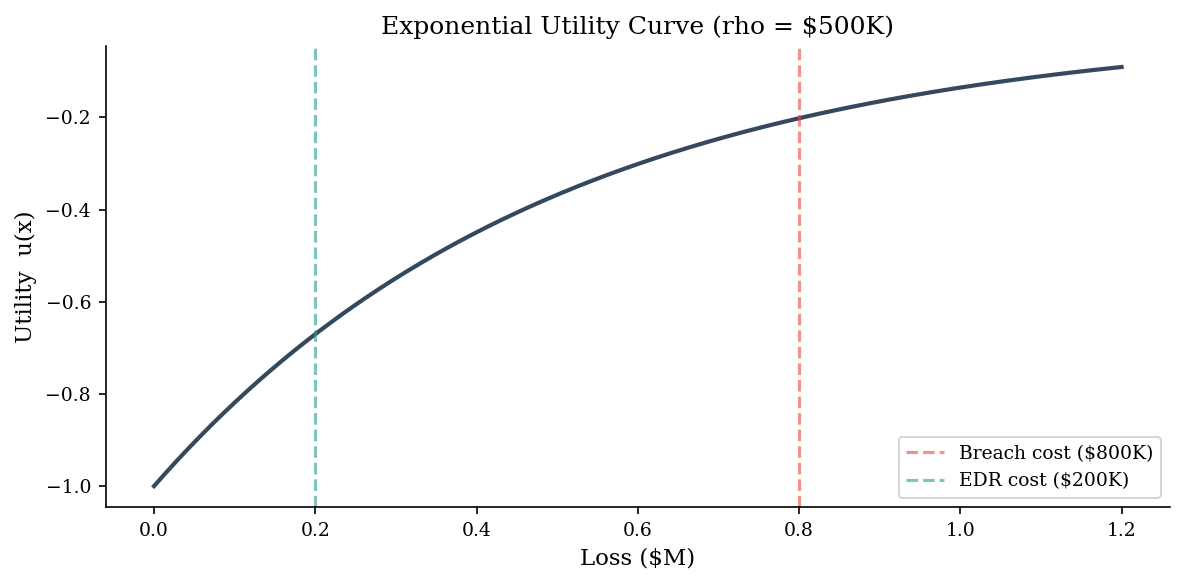

In [4]:
# Plot the utility curve
x = np.linspace(0, 1_200_000, 500)
u = utility(x)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x / 1e6, u, color=DARK_BG, linewidth=2)
ax.axvline(breach_cost / 1e6, color=ACCENT, linestyle="--", alpha=0.6, label="Breach cost ($800K)")
ax.axvline(edr_cost / 1e6, color="#2a9d8f", linestyle="--", alpha=0.6, label="EDR cost ($200K)")
ax.set_xlabel("Loss ($M)")
ax.set_ylabel("Utility  u(x)")
ax.set_title("Exponential Utility Curve (rho = $500K)")
ax.legend()
plt.tight_layout()
plt.show()

The concavity of the utility curve is what drives risk aversion: the marginal disutility of each additional dollar of loss *increases*. This is why the risk-averse decision-maker prefers the certain $\$200\text{K}$ over a 30% chance of $\$800\text{K}$, even though the expected cost of waiting ($\$240\text{K}$) is only slightly higher.

The gap between the EV-optimal choice and the EU-optimal choice widens as the stakes grow. For small decisions the two frameworks agree; for decisions near the organization's pain threshold, risk aversion dominates. This is precisely the regime where security investments tend to live.

## Monte Carlo Decision Analysis

When outcomes are continuous distributions rather than a handful of scenarios, closed-form EV calculations become unwieldy. Monte Carlo simulation handles this naturally: draw thousands of samples from your loss and cost distributions, compute utility for each, and compare the resulting distributions of outcomes across options.

We simulate the pure loss distributions for both scenarios — no costs mixed in. The control cost enters once in the decision comparison, not inside the simulation. This keeps the loss distributions clean and the economics simple: if mean risk reduction > annual control cost, the control pays for itself.

Comparing full distributions — not just means — reveals insights that a single number hides. Two options may have the same average outcome, but one has a long left tail representing catastrophic losses. A risk-averse organization should care about that tail, and simulation makes it visible. Overlaying the CDFs of two options immediately shows the probability of exceeding any given loss threshold — a far richer picture than comparing two point estimates.

> **Note:** This is deliberately the simplest possible investment calculation. A real analysis would consider: net present value (NPV) with discount rates, recurring vs. one-time costs (licensing, staffing, maintenance), implementation timelines and partial-year exposure, correlation between controls (deploying EDR may reduce the value of a separate SIEM investment), and opportunity cost of the budget. We cover those in later modules — here the goal is to show that even a basic simulation beats a point estimate.

In [5]:
severity = make_lognormal_severity(meanlog=12.2, sdlog=1.0)  # ~$200K median
n_periods = 10_000

# Pure loss distributions — no costs mixed in
losses_no_edr  = simulate_aggregate_losses(n_periods, lam=1.2, severity_sampler=severity, rng=make_rng(42))
losses_with_edr = simulate_aggregate_losses(n_periods, lam=0.6, severity_sampler=severity, rng=make_rng(42))

print('--- No EDR (pure risk) ---')
bands_no = risk_bands(losses_no_edr)
for k, v in bands_no.items():
    print(f'  {k}: ${v:,.0f}')

print()
print('--- With EDR (pure risk) ---')
bands_edr = risk_bands(losses_with_edr)
for k, v in bands_edr.items():
    print(f'  {k}: ${v:,.0f}')

print()
risk_reduction = losses_no_edr - losses_with_edr
print(f'Mean risk reduction:  ${risk_reduction.mean():,.0f}')
print(f'EDR annual cost:      ${edr_cost:,.0f}')
print(f'Net annual value:     ${risk_reduction.mean() - edr_cost:,.0f}')


--- No EDR (pure risk) ---
  p50: $194,829
  p90: $1,033,951
  p95: $1,482,220

--- With EDR (pure risk) ---
  p50: $0
  p90: $606,329
  p95: $948,906

Mean risk reduction:  $194,211
EDR annual cost:      $200,000
Net annual value:     $-5,789


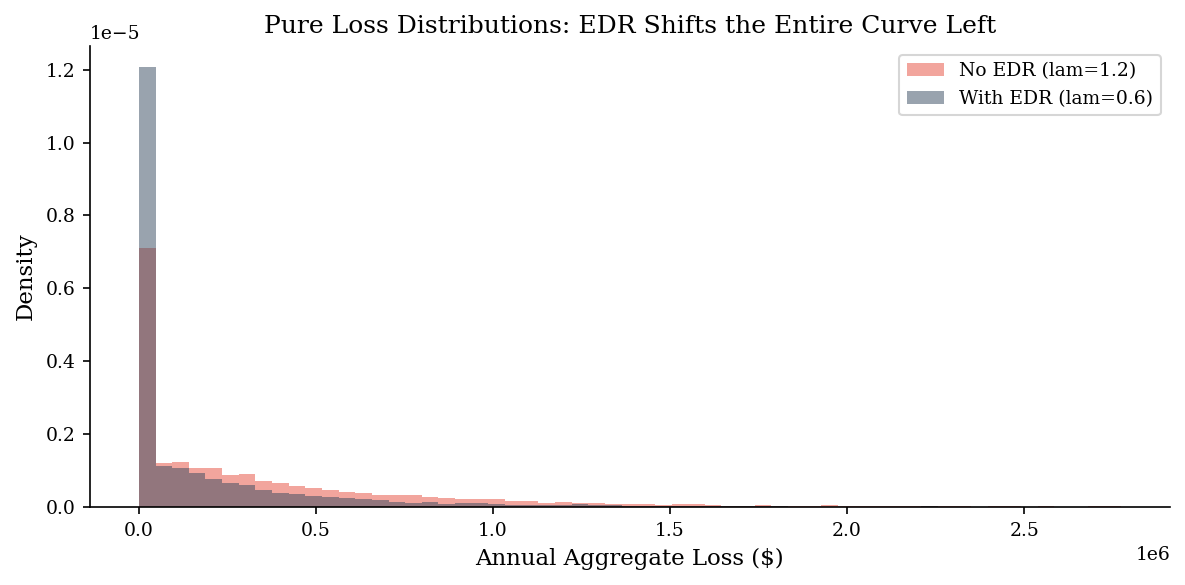

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, np.percentile(losses_no_edr, 99), 60)
ax.hist(losses_no_edr, bins=bins, alpha=0.5, density=True, label='No EDR (lam=1.2)', color=ACCENT)
ax.hist(losses_with_edr, bins=bins, alpha=0.5, density=True, label='With EDR (lam=0.6)', color=DARK_BG)
ax.set_xlabel('Annual Aggregate Loss ($)')
ax.set_ylabel('Density')
ax.set_title('Pure Loss Distributions: EDR Shifts the Entire Curve Left')
ax.legend()
plt.tight_layout()
plt.show()


## EVPI: Expected Value of Perfect Information

Before spending $\$500\text{K}$ on a threat-intelligence platform to refine your estimates, ask: *what is the most that perfect information could be worth?* The **Expected Value of Perfect Information (EVPI)** answers this. It is the difference between the expected payoff if you could know the true state of the world before deciding and the expected payoff of the best decision under current uncertainty.

How much should we pay for a perfect oracle that tells us whether a breach will happen this year? EVPI answers this. We build a **loss matrix** with shape `(S, D)` — S scenarios, D decisions — and pass it to `evpi()`.

EVPI is especially useful as a **triage tool**. Early in a risk assessment, many parameters are uncertain. Computing EVPI for each parameter tells you which uncertainties actually matter for the decision and which are "don't care" variables. If the decision is the same whether breach probability is 3% or 12%, there is no point commissioning a study to narrow that range. Focus data-collection effort where EVPI is highest — that is where better information changes what you *do*, not just what you *believe*.

In [7]:
# Loss matrix: rows = scenarios, columns = decisions
# "Wait" = accept full risk; "Deploy" = pay EDR cost + reduced risk
loss_matrix = np.column_stack([losses_no_edr, losses_with_edr + edr_cost])

evpi_val = evpi(loss_matrix)
print(f'EVPI: ${evpi_val:,.0f}')
print(f'This is the most you should pay for perfect foresight about whether a breach will occur.')


EVPI: $-222,646
This is the most you should pay for perfect foresight about whether a breach will occur.


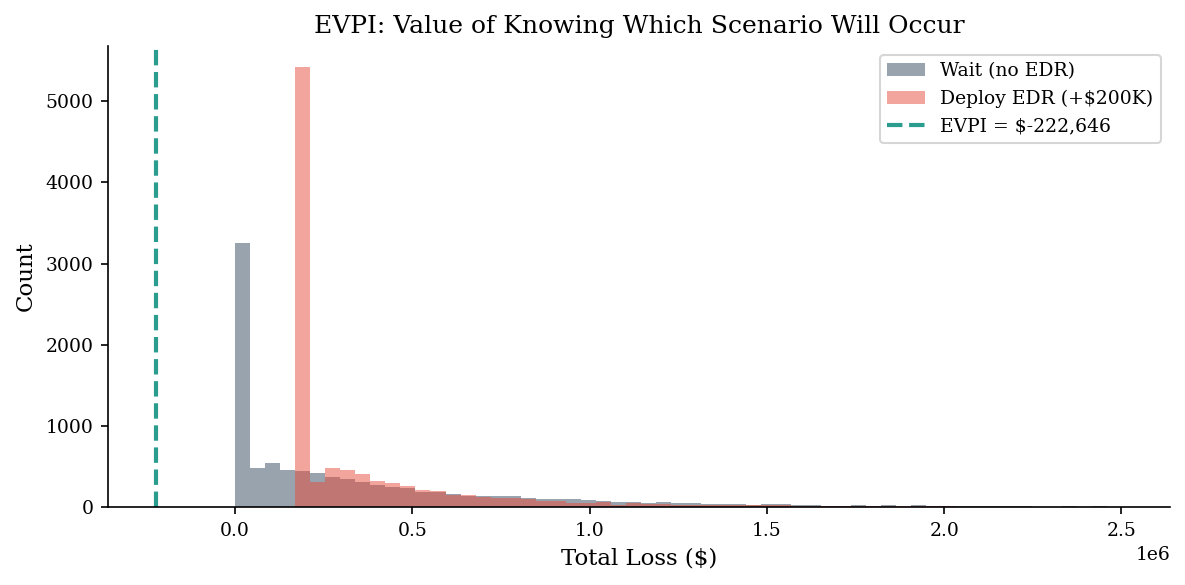

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, np.percentile(loss_matrix, 99), 60)
ax.hist(loss_matrix[:, 0], bins=bins, alpha=0.5, color=DARK_BG, label="Wait (no EDR)")
ax.hist(loss_matrix[:, 1], bins=bins, alpha=0.5, color=ACCENT, label="Deploy EDR (+$200K)")

# Show where perfect info helps: the overlap region
ax.axvline(evpi_val, color="#2a9d8f", linestyle="--", linewidth=2, label=f"EVPI = ${evpi_val:,.0f}")
ax.set_xlabel("Total Loss ($)")
ax.set_ylabel("Count")
ax.set_title("EVPI: Value of Knowing Which Scenario Will Occur")
ax.legend()
plt.tight_layout()
plt.show()

EVPI tells you the *ceiling* on what better information is worth. If EVPI is $\$15\text{K}$, spending $\$50\text{K}$ on a threat intelligence platform to resolve this uncertainty is overpaying — no amount of data collection could improve your decision by more than $\$15\text{K}$. If EVPI is $\$200\text{K}$, even an expensive assessment could pay for itself.

> **Tip:** A quick EVPI sanity check: if the best and worst plausible values of a parameter lead to the same decision, that parameter has zero information value for this decision. You can stop debating it and move on. This alone can cut meeting time in half during risk workshops.

> **In practice:** EVPI assumes you could get *perfect* information, which never happens. The realistic metric is EVSI (Expected Value of Sample Information) — what a specific, imperfect source of data is actually worth. That requires modeling the information source's accuracy, which we cover next.

## EVSI: What Is Imperfect Information Actually Worth?

EVPI is a ceiling — it assumes you could learn the true state of the world with certainty. Real information sources are noisy: a penetration test reveals some vulnerabilities but not all, a threat-intelligence feed is directionally correct but not perfect. **EVSI (Expected Value of Sample Information)** extends the framework to handle imperfect evidence.

The calculation follows Raiffa's (1968) structure:

1. For each possible **signal** the information source might produce, compute the **posterior probability** of each state using Bayes' theorem.
2. Determine the **optimal action** given that posterior.
3. Weight by the **probability of receiving each signal**.
4. The difference between this expected value and the expected value of the best unconditional action is the EVSI.

**Scenario:** Before deciding on EDR deployment, the CISO can commission a $\$50\text{K}$ threat assessment. The assessment has 80% accuracy — it correctly predicts whether a breach will occur 80% of the time (i.e., 80% true positive rate, 80% true negative rate).

$$\text{EVSI} = \mathbb{E}_{\text{signal}}\bigl[V^*(\text{posterior})\bigr] - V^*(\text{prior})$$

If EVSI $< \$50\text{K}$, the assessment costs more than the decision value it provides. If EVSI $> \$50\text{K}$, it pays for itself.

EVSI is especially valuable for **comparing information sources** with different costs and accuracies. A $\$10\text{K}$ vulnerability scan with 60% accuracy might have higher EVSI-per-dollar than a $\$100\text{K}$ red-team engagement with 90% accuracy, depending on the decision context. The key insight from Raiffa: the value of information depends not just on its accuracy but on how much the decision *changes* in response to the information. If you would deploy EDR regardless of what the assessment finds, the assessment has zero decision value no matter how accurate it is.

In [9]:
# EVSI: Expected Value of Sample Information
# Threat assessment with 80% accuracy (TPR=0.8, TNR=0.8)

tpr = 0.80  # P(assessment says "breach" | breach will occur)
tnr = 0.80  # P(assessment says "safe" | no breach)

# Using the EDR scenario parameters from above
# breach_prob = 0.3, breach_cost = 800_000, edr_cost = 200_000

# P(assessment says "breach")
p_says_breach = tpr * breach_prob + (1 - tnr) * (1 - breach_prob)
# P(assessment says "safe")
p_says_safe = 1 - p_says_breach

# Posterior probabilities via Bayes
p_breach_given_says_breach = (tpr * breach_prob) / p_says_breach
p_breach_given_says_safe = ((1 - tpr) * breach_prob) / p_says_safe

# Optimal decision given each assessment outcome
# If assessment says "breach": compare EV(deploy) vs EV(wait)
ev_deploy = edr_cost  # certain
ev_wait_if_breach_signal = p_breach_given_says_breach * breach_cost
best_if_breach_signal = min(ev_deploy, ev_wait_if_breach_signal)

ev_wait_if_safe_signal = p_breach_given_says_safe * breach_cost
best_if_safe_signal = min(ev_deploy, ev_wait_if_safe_signal)

# Expected value WITH the assessment
ev_with_assessment = p_says_breach * best_if_breach_signal + p_says_safe * best_if_safe_signal

# Expected value WITHOUT (best unconditional decision)
ev_without = min(ev_deploy, breach_prob * breach_cost)

evsi = ev_without - ev_with_assessment

print(f"P(assessment says 'breach') = {p_says_breach:.2f}")
print(f"P(assessment says 'safe')   = {p_says_safe:.2f}")
print()
print(f"If 'breach' signal: P(actual breach) = {p_breach_given_says_breach:.1%}")
print(f"  -> Best action: {'Deploy' if ev_deploy < ev_wait_if_breach_signal else 'Wait'} (EV = ${best_if_breach_signal:,.0f})")
print(f"If 'safe' signal:   P(actual breach) = {p_breach_given_says_safe:.1%}")
print(f"  -> Best action: {'Deploy' if ev_deploy < ev_wait_if_safe_signal else 'Wait'} (EV = ${best_if_safe_signal:,.0f})")
print()
print(f"EV without assessment: ${ev_without:,.0f}")
print(f"EV with assessment:    ${ev_with_assessment:,.0f}")
print(f"EVSI:                  ${evsi:,.0f}")
print()
assessment_cost = 50_000
if evsi > assessment_cost:
    print(f"The assessment (${assessment_cost:,.0f}) is worth commissioning (EVSI > cost).")
else:
    print(f"The assessment (${assessment_cost:,.0f}) costs more than its decision value (EVSI < cost).")

P(assessment says 'breach') = 0.38
P(assessment says 'safe')   = 0.62

If 'breach' signal: P(actual breach) = 63.2%
  -> Best action: Deploy (EV = $200,000)
If 'safe' signal:   P(actual breach) = 9.7%
  -> Best action: Wait (EV = $77,419)

EV without assessment: $200,000
EV with assessment:    $124,000
EVSI:                  $76,000

The assessment ($50,000) is worth commissioning (EVSI > cost).


## Opportunity Loss: Reframing as Regret

Raiffa introduced an alternative framing that security audiences often find more intuitive: instead of computing what each action is *worth*, compute what you *give up* by choosing the wrong action in each possible state. This is the **opportunity loss** or **regret** for each state-action pair.

For any decision, the opportunity loss of an action in a given state is the difference between the cost of that action and the cost of the *best possible* action for that state. The **Expected Opportunity Loss (EOL)** weights these regrets by state probabilities.

A remarkable property: **the EOL of the optimal action always equals the EVPI.** This provides both a sanity check on calculations and an intuitive interpretation — EVPI is the expected regret of having to decide under uncertainty. In security terms, it answers: "on average, how much do we leave on the table because we don't know which scenario will materialize?"

The regret framing resonates with stakeholders who think in terms of missed opportunities rather than expected values. Presenting both — the EV comparison and the opportunity-loss table — gives decision-makers two independent lenses on the same problem and makes the reasoning more robust to cognitive biases.

In [10]:
# Opportunity Loss Table
# States: Breach, No Breach
# Actions: Deploy EDR, Wait

import pandas as pd

# Costs in each state (lower is better — these are losses)
payoff_matrix = pd.DataFrame(
    {
        "Deploy EDR": [edr_cost, edr_cost],           # $200K either way
        "Wait":       [breach_cost, 0],                 # $800K if breach, $0 if not
    },
    index=["Breach (p=0.3)", "No Breach (p=0.7)"],
)

# Best achievable in each state
best_per_state = payoff_matrix.min(axis=1)

# Opportunity loss = actual cost - best possible cost in that state
opp_loss = payoff_matrix.subtract(best_per_state, axis=0)

print("=== Cost Matrix ===")
print(payoff_matrix.to_string())
print()
print("=== Opportunity Loss ===")
print(opp_loss.to_string())
print()

# Expected opportunity loss
probs = np.array([breach_prob, 1 - breach_prob])
eol = opp_loss.T @ probs
print("=== Expected Opportunity Loss ===")
for action, val in eol.items():
    print(f"  {action}: ${val:,.0f}")

print(f"\nEVPI = EOL of best action = ${eol.min():,.0f}")
print("(Matches the EVPI computed above — this is always true.)")

=== Cost Matrix ===
                   Deploy EDR    Wait
Breach (p=0.3)         200000  800000
No Breach (p=0.7)      200000       0

=== Opportunity Loss ===
                   Deploy EDR    Wait
Breach (p=0.3)              0  600000
No Breach (p=0.7)      200000       0

=== Expected Opportunity Loss ===
  Deploy EDR: $140,000
  Wait: $180,000

EVPI = EOL of best action = $140,000
(Matches the EVPI computed above — this is always true.)


## Control Selection Under Budget Constraints

Given a menu of candidate controls — EDR, MFA rollout, network segmentation, backup hardening — each with an estimated cost and risk-reduction effect, a **greedy ROI approach** ranks them by risk reduction per dollar and fills the budget from the top. This is fast, intuitive, and often close to optimal for modest portfolios.

For example, if MFA costs $\$80\text{K}$ and reduces expected loss by $\$600\text{K}$ while EDR costs $\$200\text{K}$ and reduces expected loss by $\$900\text{K}$, MFA's ROI ($\$7.50$ per dollar) beats EDR's ($\$4.50$ per dollar). Under a $\$250\text{K}$ budget you would select MFA first, then EDR with the remaining $\$170\text{K}$ — except EDR is indivisible, so you need to check whether a second cheaper control fits instead. The code below walks through this selection process step by step.

> **Note:** The greedy approach assumes control effects are independent: deploying MFA does not change the risk-reduction value of EDR. In practice, controls interact — overlapping detective controls may have diminishing marginal returns, while complementary controls (prevention + detection) may multiply effectiveness. Later chapters introduce optimization methods that can handle some of these interactions.

In [11]:
control_names = ["EDR", "WAF", "MFA", "SIEM", "Pen Test"]
deltas = [120_000, 80_000, 150_000, 60_000, 40_000]   # annual risk reduction
costs  = [200_000, 50_000, 30_000, 180_000, 25_000]    # annual cost
budget = 300_000

chosen_idx, total_cost, total_delta = select_controls_by_roi(deltas, costs, budget)

print(f"Budget: ${budget:,}")
print(f"\nSelected controls (by ROI rank):")
for i in chosen_idx:
    roi = deltas[i] / costs[i]
    print(f"  {control_names[i]:>10s}  cost=${costs[i]:>8,}  delta=${deltas[i]:>8,}  ROI={roi:.2f}")

print(f"\nTotal spend: ${total_cost:,.0f} / ${budget:,}")
print(f"Total risk reduction: ${total_delta:,.0f}")
print(f"Unspent budget: ${budget - total_cost:,.0f}")

Budget: $300,000

Selected controls (by ROI rank):
         MFA  cost=$  30,000  delta=$ 150,000  ROI=5.00
         WAF  cost=$  50,000  delta=$  80,000  ROI=1.60
    Pen Test  cost=$  25,000  delta=$  40,000  ROI=1.60
        SIEM  cost=$ 180,000  delta=$  60,000  ROI=0.33

Total spend: $285,000 / $300,000
Total risk reduction: $330,000
Unspent budget: $15,000


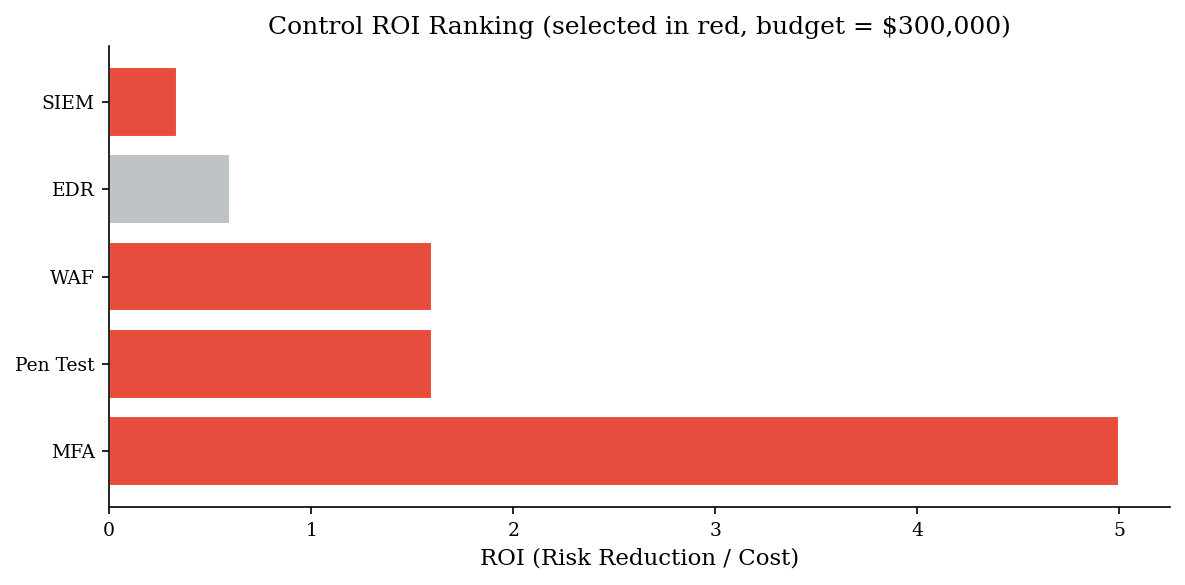

In [12]:
roi = np.array(deltas) / np.array(costs)
order = np.argsort(roi)[::-1]
bar_colors = [ACCENT if i in chosen_idx else VERY_LIGHT for i in order]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([control_names[i] for i in order],
        [roi[i] for i in order],
        color=bar_colors, edgecolor='white')
ax.set_xlabel('ROI (Risk Reduction / Cost)')
ax.set_title(f'Control ROI Ranking (selected in red, budget = ${budget:,.0f})')
plt.tight_layout()
plt.show()

## Pitfalls

Decision-theoretic analysis is only as good as its inputs and structure. Four recurring traps in security:

**Means hide variance.** Reporting that the "expected annual loss is $\$2\text{M}$" obscures the difference between a near-certain $\$2\text{M}$ loss and a 1% chance of $\$200\text{M}$. Always present distributional summaries (percentiles, density plots), not just point estimates. EV analysis above says "Wait" is cheaper by $\$40\text{K}$, but the no-EDR distribution has a much heavier right tail. A single bad year wipes out many years of savings.

**Omitting costs.** A control that "reduces risk by 40%" looks great until you account for license fees, staffing, maintenance, and the productivity drag of false positives. Include total cost of ownership in every branch of the tree.

**Double-counting.** Reputation damage and revenue loss often overlap — the revenue drops *because* of the reputation hit. Counting both at full value inflates the benefit of mitigation and distorts the analysis.

**Ignoring the "do nothing" baseline.** Every option should be compared against the status quo, not against zero. If current controls already reduce expected loss by 60%, the marginal value of an additional control is measured against that baseline, not against an unprotected state.

## What We Left Out

This notebook intentionally simplifies to teach the core mechanics. Production-grade decision analysis would also address several additional dimensions:

- **Time value of money.** A dollar of risk reduction next year is worth less than a dollar today. Discounting future costs and benefits via NPV is standard in finance but often skipped in security analyses.
- **Correlated risks.** A single breach event may trigger regulatory fines, litigation, customer churn, and operational downtime simultaneously. Modeling these as independent overstates diversification.
- **Real options.** Some decisions are irreversible (decommissioning a legacy system) while others are deferrable (waiting for next-gen tooling). Real-options thinking values the flexibility to wait, which pure EV analysis ignores.
- **Portfolio effects.** Controls interact as a system. The marginal value of a detective control depends on what preventive controls are already in place. Later chapters address portfolio-level modeling.

These simplifications are deliberate: the goal of this notebook is to build intuition for structured decision-making, not to produce a production-grade model on the first pass. Even the simplest quantitative framing — distributions + expected utility + EVPI — outperforms gut feel.